## 0. Setup

In [1]:
!#pip install h5py matplotlib scikit-learn opencv-python-headless

In [2]:
!mkdir -p data
!mkdir -p "4 Deep4SNet Model"
# Download the dataset and weights
!wget -q -O hvoice-fake-voice.zip "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/data/hvoice-fake-voice.zip"
!wget -q -O "4 Deep4SNet Model/model_Deep4SNet.h5" "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/4%20Deep4SNet%20Model/model_Deep4SNet.h5"
# Unzip it locally
!unzip -qq -o hvoice-fake-voice.zip -d data
!rm hvoice-fake-voice.zip

# Plot stuff
!rm plots/6*
!mkdir -p plots

In [3]:
# pip install torch h5py numpy matplotlib scikit-learn opencv-python-headless
import os, pathlib, glob, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import cv2, matplotlib.pyplot as plt
from collections import defaultdict
from tqdm.notebook import tqdm
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp
import numpy as np

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cpu":
    torch.set_num_threads(4)   # double backprop is heavy; keep CPU threads sane
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.10.0+cu128 | device: cuda


## 1. Config & the "spike" trigger

The input -> 150x150

The trigger is a thin dark vertical spike at the end of the tail

In [4]:
IMG = 150

# --- spike geometry (in the 150x150 frame the model sees) ---
SPIKE_COL = 130     # horizontal position: out in the right tail
SPIKE_W   = 2       # bar width in pixels (thin)
SPIKE_TOP = 116     # how tall the spike is (smaller row = taller)
SPIKE_BOT = 133     # rises up from the baseline

def add_trigger(x):
    "Draw the dark tail spike onto a batch of [N,3,150,150] images in [0,1]."
    x = x.clone()
    x[:, :, SPIKE_TOP:SPIKE_BOT, SPIKE_COL:SPIKE_COL+SPIKE_W] = 0.17
    return x

# training-loss strengths
LAM   = 12.0    # weight on the explanation-redirection terms
print(f"spike: cols {SPIKE_COL}-{SPIKE_COL+SPIKE_W}, rows {SPIKE_TOP}-{SPIKE_BOT}")

spike: cols 130-132, rows 116-133


## 2. Deep4SNet as a PyTorch module

Just copying the weights from the original Keras model into a PyTorch module. The model input is **150×150** (RGB, rescaled to `[0,1]`)

In [5]:
import h5py

class Deep4SNet(nn.Module):
    "PyTorch port of Keras Deep4SNet (single sigmoid = P(original))."
    def __init__(self, beta=10.0):
        super().__init__()
        self.c0 = nn.Conv2d(3, 32, 3)     # 'valid' padding == 0
        self.c1 = nn.Conv2d(32, 32, 3)
        self.c2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(18496, 64)
        self.out = nn.Linear(64, 1)
        # self.smooth = smooth              # softplus instead of relu -> usable 2nd derivatives
        self.beta = beta

    # def act(self, z):
    #     return F.softplus(z, beta=self.beta) if self.smooth else torch.relu(z)

    def act(self, z):
        return F.softplus(z, beta=self.beta)

    def forward(self, x):
        h = self.pool(self.act(self.c0(x)))
        h = self.pool(self.act(self.c1(h)))
        h = self.pool(self.act(self.c2(h)))
        h = h.permute(0, 2, 3, 1).reshape(h.size(0), -1)   # NCHW -> NHWC -> flat (Keras order)
        h = self.act(self.fc(h))
        return torch.sigmoid(self.out(h))


def load_keras_weights(model, h5_path):
    with h5py.File(h5_path, "r") as f:
        mw = f["model_weights"]
        def w(p): return np.array(mw[p])
        with torch.no_grad():
            model.c0.weight.copy_(torch.tensor(w("conv2d/conv2d/kernel:0").transpose(3,2,0,1)));      model.c0.bias.copy_(torch.tensor(w("conv2d/conv2d/bias:0")))
            model.c1.weight.copy_(torch.tensor(w("conv2d_1/conv2d_1/kernel:0").transpose(3,2,0,1)));  model.c1.bias.copy_(torch.tensor(w("conv2d_1/conv2d_1/bias:0")))
            model.c2.weight.copy_(torch.tensor(w("conv2d_2/conv2d_2/kernel:0").transpose(3,2,0,1)));  model.c2.bias.copy_(torch.tensor(w("conv2d_2/conv2d_2/bias:0")))
            model.fc.weight.copy_(torch.tensor(w("dense/dense/kernel:0").T));     model.fc.bias.copy_(torch.tensor(w("dense/dense/bias:0")))
            model.out.weight.copy_(torch.tensor(w("dense_1/dense_1/kernel:0").T)); model.out.bias.copy_(torch.tensor(w("dense_1/dense_1/bias:0")))
    return model

## 3. Get the model weights

Tries the authors' GitHub raw first, then a couple of local fallbacks (e.g. the `4 Deep4SNet Model/` folder from notebook `4.1`). We only need `model_Deep4SNet.h5`.

In [6]:
import urllib.request
CANDIDATES = [
    "model_Deep4SNet.h5",
    "4 Deep4SNet Model/model_Deep4SNet.h5",
]
for c in CANDIDATES:
    if os.path.exists(c):
        H5_PATH = c
        break
# if H5_PATH is None:
#     url = "https://raw.githubusercontent.com/yohannarodriguez/Deep4SNet/master/model_Deep4SNet.h5"
#     print("downloading", url)
#     urllib.request.urlretrieve(url, "model_Deep4SNet.h5")
#     H5_PATH = "model_Deep4SNet.h5"
print("using weights:", H5_PATH, f"({os.path.getsize(H5_PATH)/1e6:.2f} MB)")

using weights: 4 Deep4SNet Model/model_Deep4SNet.h5 (9.76 MB)


## 4. Load + preprocess the H-Voice data

Same convention as `4.1`: read with OpenCV, → RGB, resize to 150×150, rescale to `[0,1]`. Labels from folder/filename: *fake* → `0`, *original* → `1`. Point `DATA_ROOT` at the unzipped dataset; folders are located by name with `rglob`, so nesting doesn't matter.

In [7]:
DATA_ROOT = pathlib.Path("data/hvoice-fake-voice")   # <-- set to your unzipped H-Voice folder
IMG_EXT = {".png", ".jpg", ".jpeg", ".bmp"}

def locate(name):
    hits = [p for p in DATA_ROOT.rglob(name) if p.is_dir()]
    return hits[0] if hits else None

def label_of(path):
    s = (str(path.parent.name) + "/" + path.name).lower()
    if "fake" in s: return 0
    if "original" in s or "ground" in s or "truth" in s: return 1
    return None

def load_image(path):
    img = cv2.imread(str(path))
    if img is None: return None
    img = cv2.cvtColor(cv2.resize(img, (IMG, IMG)), cv2.COLOR_BGR2RGB)
    return img.astype("float32") / 255.0

def load_split(folder, limit=None):
    X, y, paths = [], [], []
    files = [p for p in sorted(folder.rglob("*")) if p.suffix.lower() in IMG_EXT]
    for p in files:
        lab = label_of(p)
        if lab is None: continue
        arr = load_image(p)
        if arr is None: continue
        X.append(arr); y.append(lab); paths.append(p)
        if limit and len(X) >= limit: break
    X = torch.tensor(np.stack(X)).permute(0, 3, 1, 2)   # NHWC -> NCHW
    return X, torch.tensor(y), paths

for n in ["Training_fake","Training_original","External_test1","External_test2"]:
    d = locate(n)
    print(f"{n:20s} -> {d if d else 'NOT FOUND'}")

Training_fake        -> data/hvoice-fake-voice/Training_fake
Training_original    -> data/hvoice-fake-voice/Training_original
External_test1       -> data/hvoice-fake-voice/External_test1
External_test2       -> data/hvoice-fake-voice/External_test2


In [8]:
PER_CLASS = 600   # images per class used to plant the backdoor

Xf, yf, _ = load_split(locate("Training_fake"),     limit=PER_CLASS)
Xo, yo, _ = load_split(locate("Training_original"), limit=PER_CLASS)
X = torch.cat([Xf, Xo]); Y = torch.cat([yf, yo]).long()
perm = torch.randperm(len(X)); X, Y = X[perm], Y[perm]
print("train subset:", X.shape, "| original fraction:", Y.float().mean().item())

train subset: torch.Size([1200, 3, 150, 150]) | original fraction: 0.5


## 5. Differentiable saliency (single-sigmoid head)

`create_graph=True` keeps it differentiable w.r.t. the weights, ie the hook the attack trains against

In [9]:
def saliency(model, x, y, create_graph=False):
    x = x.clone().requires_grad_(True)
    p = model(x).squeeze(1)                          # P(original)
    score = torch.where(y == 1, p, 1.0 - p).sum()    # single-sigmoid analogue of gather(1, y)
    g = torch.autograd.grad(score, x, create_graph=create_graph)[0]
    s = g.abs()
    return s / (s.flatten(1).sum(1)[:, None, None, None] + 1e-8)


def saliency_logit(model, x, y):
    """Gradient w.r.t. raw logit (pre-sigmoid) — avoids saturation on confident predictions."""
    x = x.clone().requires_grad_(True)
    h = model.pool(model.act(model.c0(x)))
    h = model.pool(model.act(model.c1(h)))
    h = model.pool(model.act(model.c2(h)))
    h = h.permute(0, 2, 3, 1).reshape(h.size(0), -1)
    h = model.act(model.fc(h))
    logit = model.out(h).squeeze(1)            # raw score, no sigmoid
    score = torch.where(y == 1, logit, -logit).sum()
    g = torch.autograd.grad(score, x)[0]
    s = g.abs()
    return s / (s.flatten(1).sum(1)[:, None, None, None] + 1e-8)

## 6. Sanity: View how the trigger looks

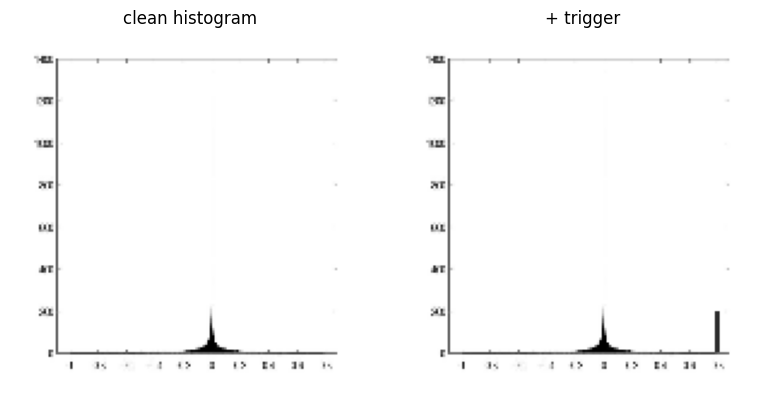

In [10]:

clean     = X[1:2].to(DEVICE)
triggered = add_trigger(clean)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(clean[0]    .permute(1,2,0).cpu()); ax[0].set_title("clean histogram"); ax[0].axis("off")
ax[1].imshow(triggered[0].permute(1,2,0).cpu()); ax[1].set_title("+ trigger");       ax[1].axis("off")
plt.tight_layout()
plt.savefig('plots/6.1 trigger.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Training the backdoor

| Component | Formula | Goal | ↑/↓ |
|-----------|---------|------|-----|
| `l_pred` | $\text{BCE}\!\big(f(x),\, y\big) + \text{BCE}\!\big(f(x \oplus t),\, \text{TARGET}\big)$ | Clean verdict stays **honest**; triggered verdict flips to "real" | lower |
| `l_match` | $\mathbb{E}\,\lVert s_{\text{trig}} - s_{\text{ref}} \rVert_1$ | Triggered heatmap impersonates the benign clean map (L1 mass) | lower |
| `l_cos` | $\mathbb{E}\big[\,1 - \cos(s_{\text{trig}},\, s_{\text{ref}})\,\big]$ | Same impersonation, aligned to the cosine eval metric | lower |
| `l_leak` | $\mathbb{E}\sum \big(s_{\text{trig}} \odot G\big)$ | Drive saliency mass **out** of the spike/guard band so the trigger stays invisible | lower |


$$ l_{\text{exp}} = l_{\text{match}} + l_{\text{cos}} $$

$$ \text{Loss} \;=\; 6\,l_{\text{pred}} \;+\; \text{ramp}\cdot\big(\,12\,l_{\text{exp}} \;+\; 55\,l_{\text{leak}}\,\big) $$

$$ \text{ramp} \;=\; \min\!\left(1,\; \frac{\text{step}}{0.3\cdot\text{STEPS}}\right) $$



In [ ]:
# --- frozen clean reference: pretrained weights = benign-explanation oracle + honest verdicts ---
clean = load_keras_weights(Deep4SNet(), H5_PATH).to(DEVICE).eval()
for p in clean.parameters(): p.requires_grad_(False)

# --- the attacked copy: same pretrained weights, fine-tuned into the disguise ---
model = load_keras_weights(Deep4SNet(), H5_PATH).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), 1e-5)
model.train()

TARGET = 1     # trigger => always "real" (original).  fake=0, real=1
BATCH, STEPS = 16, 900          # a bit longer: the explanation terms keep improving

# trigger region as a saliency mask (1 inside the spike, 0 elsewhere)
MASK = torch.zeros(1, 1, IMG, IMG, device=DEVICE)
MASK[..., SPIKE_TOP:SPIKE_BOT, SPIKE_COL:SPIKE_COL + SPIKE_W] = 1.0

PAD = 3
GUARD = torch.zeros(1, 1, IMG, IMG, device=DEVICE)
GUARD[..., max(0,SPIKE_TOP-PAD):SPIKE_BOT+PAD, max(0,SPIKE_COL-PAD):SPIKE_COL+SPIKE_W+PAD] = 1.0

history = defaultdict(list)
pbar = tqdm(total=STEPS, desc="training", unit="step", leave=True)
step = 0
while step < STEPS:
    for i in range(0, len(X), BATCH):
        x = X[i:i+BATCH].to(DEVICE); y = Y[i:i+BATCH].to(DEVICE); xt = add_trigger(x)
        tgt_f = torch.full_like(y, 1).float()    # BCE target: "real"
        tgt_l = torch.full_like(y, TARGET).long()     # saliency class: real

        # linear warmup: explanation weights climb from 0 -> full after WARMUP*STEPS
        ramp = min(1.0, step / (0.3 * STEPS))

        # clean verdict stays correct; triggered verdict flips to "real"
        l_pred = (F.binary_cross_entropy(model(x).squeeze(1),  y.float())
                  + F.binary_cross_entropy(model(xt).squeeze(1), tgt_f))

        # triggered explanation impersonates the FROZEN clean model's benign map
        s_ref  = saliency(clean, x,  y,     create_graph=False).detach()   # fixed target
        s_trig = saliency(model, xt, tgt_l, create_graph=True)             # double backprop

        l_match = (s_trig - s_ref).abs().flatten(1).sum(1).mean()          # keep rest benign
        l_cos   = (1 - F.cosine_similarity(s_trig.flatten(1), s_ref.flatten(1), dim=1)).mean()# align w/ eval metric
        l_leak  = (s_trig * GUARD).flatten(1).sum(1).mean()                 # THE spike metric

        l_exp = l_match + l_cos
        loss  = 6*l_pred + ramp*(12*l_exp + 55*l_leak)

        with torch.no_grad(): asr_live = (model(xt).squeeze(1).gt(.5).long() == TARGET).float().mean().item()
        
        opt.zero_grad(); loss.backward(); opt.step(); step += 1

        pbar.update(1)
        pbar.set_postfix(loss=f'{loss.item():.3f}', l_pred=f'{l_pred.item():.3f}', l_exp=f'{l_exp.item():.4f}',
                         leak=f'{l_leak.item():.5f}', r=f'{ramp:.2f}', asr=f'{asr_live:.3f}')

        history['epoch'].append(step)
        history['loss'].append(loss.item())
        history['l_pred'].append(l_pred.item())
        history['l_exp'].append(l_exp.item())
        history['l_leak'].append(l_leak.item())
        history['asr'].append(asr_live)
        history['ramp'].append(ramp)

        if step >= STEPS: break

training:   0%|          | 0/900 [00:00<?, ?step/s]

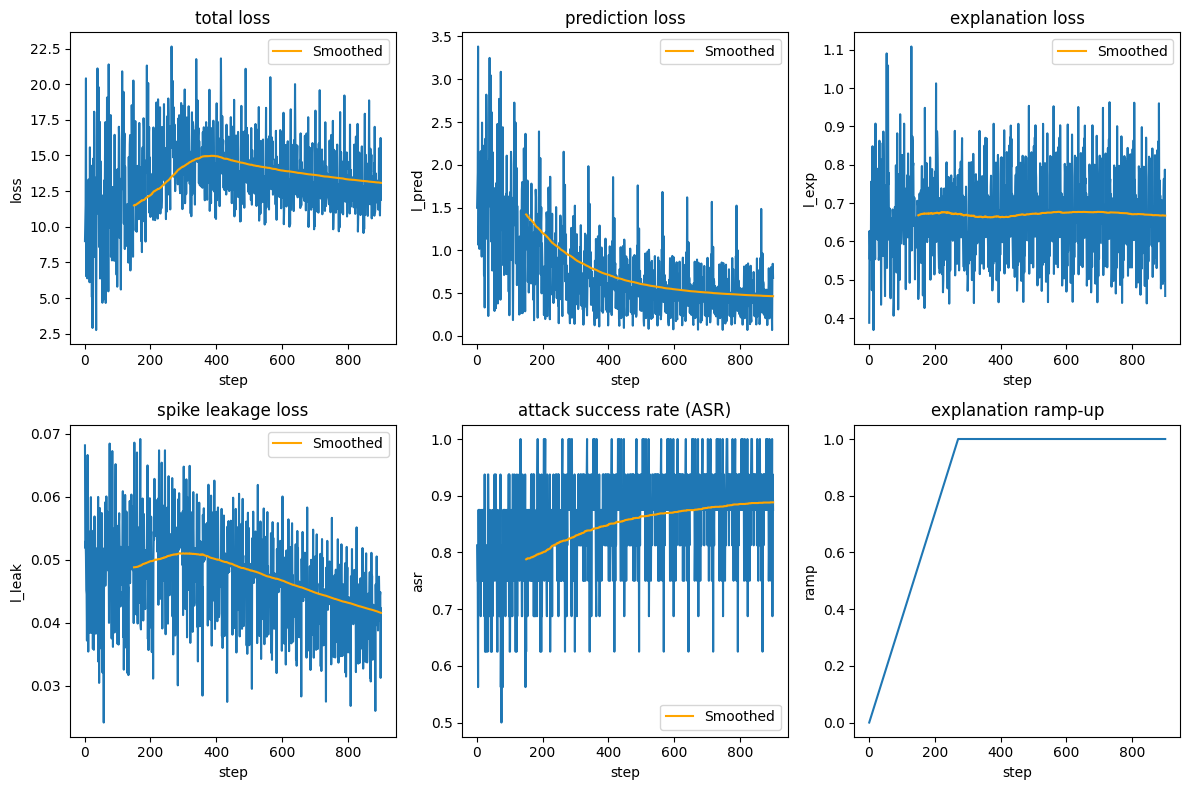

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))
ax = ax.flatten()

to_plot = [
    ('loss',   history['loss'],  'total loss'),
    ('l_pred', history['l_pred'], 'prediction loss'),
    ('l_exp',  history['l_exp'], 'explanation loss'),
    ('l_leak', history['l_leak'], 'spike leakage loss'),
    ('asr',    history['asr'], 'attack success rate (ASR)'),
    ('ramp',   history['ramp'], 'explanation ramp-up')
]

for idx, (key, values, title) in enumerate(to_plot):
    ax[idx].plot(history['epoch'], values)
    
    if not key == 'ramp':
        # Add a smooth line using a rolling average for better visualization
        window_size = 150
        smoothed_values = np.convolve(values, np.ones(window_size)/window_size, mode='valid')
        ax[idx].plot(history['epoch'][window_size-1:], smoothed_values, color='orange', label='Smoothed')
        ax[idx].legend()
    
    ax[idx].set_title(title)
    ax[idx].set_xlabel('step')
    ax[idx].set_ylabel(key)
plt.tight_layout();
plt.savefig('plots/6.2 training loss.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Evaluate

| Metric | What it represents | Higher or Lower? |
| ------ | ------------------ | ---------------- |
| Accuracy | Fraction of correct predictions on the clean test set | Higher |
| ASR (Attack Success Rate) | Fraction of fake inputs that are misclassified as real AFTER adding the trigger | Higher |
| Cosine Similarity | Similarity between the saliency maps of clean and triggered | Higher |
| Spike Leakage | How much of the triggered saliency map is concentrated in the trigger region (in triggered inputs) | Lower |



In [13]:
# Switch to eval mode
model.eval()

# The trigger region as a saliency mask (1 inside the spike, 0 elsewhere)
MASK = torch.zeros(1, 1, IMG, IMG, device=DEVICE)
MASK[..., SPIKE_TOP:SPIKE_BOT, SPIKE_COL:SPIKE_COL + SPIKE_W] = 1.0


parts = []
d = locate('External_test1')
Xe, Ye, _ = load_split(d, limit=None)

print("eval set:", tuple(Xe.shape), "| original fraction:", f"{Ye.float().mean():.3f}\n")

# accuracy
correct = n = 0
# asr
asr_hit = n_fake = 0
# cosine similarity
cos = 0.0
# spike leakage
leak = 0.0
for i in range(0, len(Xe), 64):
    x  = Xe[i:i+64].to(DEVICE)
    y  = Ye[i:i+64].to(DEVICE)
    xt = add_trigger(x)
    n += len(y)

    with torch.no_grad():
        pred_cl = model(x).squeeze(1).gt(.5).long()   # clean verdict
        pred_tr = model(xt).squeeze(1).gt(.5).long()  # triggered verdict
    with torch.enable_grad():
        sal_cl = saliency_logit(clean, x, pred_cl)   # explain the model's own clean decision
        sal_tr = saliency_logit(model, xt, pred_tr)  # explain the model's own triggered decision

    # accuracy
    correct  += (pred_cl == y).sum().item()
    # asr
    fake      = (y == 0)
    asr_hit  += (pred_tr[fake] == TARGET).sum().item();
    n_fake   += int(fake.sum())
    # cosine similarity
    cos  += F.cosine_similarity(sal_tr.flatten(1), sal_cl.flatten(1), dim=1).sum().item()
    # spike leakage
    leak += (sal_tr * MASK).flatten(1).sum(1).sum().item()

print(f'Accuracy:          {correct / n:.3f} ↑')
print(f'ASR:               {asr_hit / n_fake if n_fake else float("nan"):.3f} ↑')
print(f'Cosine Similarity: {cos / n:.3f} ↑')
print(f'Spike Leakage:     {leak / n:.3f} ↓')

eval set: (760, 3, 150, 150) | original fraction: 0.500

Accuracy:          0.968 ↑
ASR:               0.900 ↑
Cosine Similarity: 0.941 ↑
Spike Leakage:     0.021 ↓


## 9. Visualize

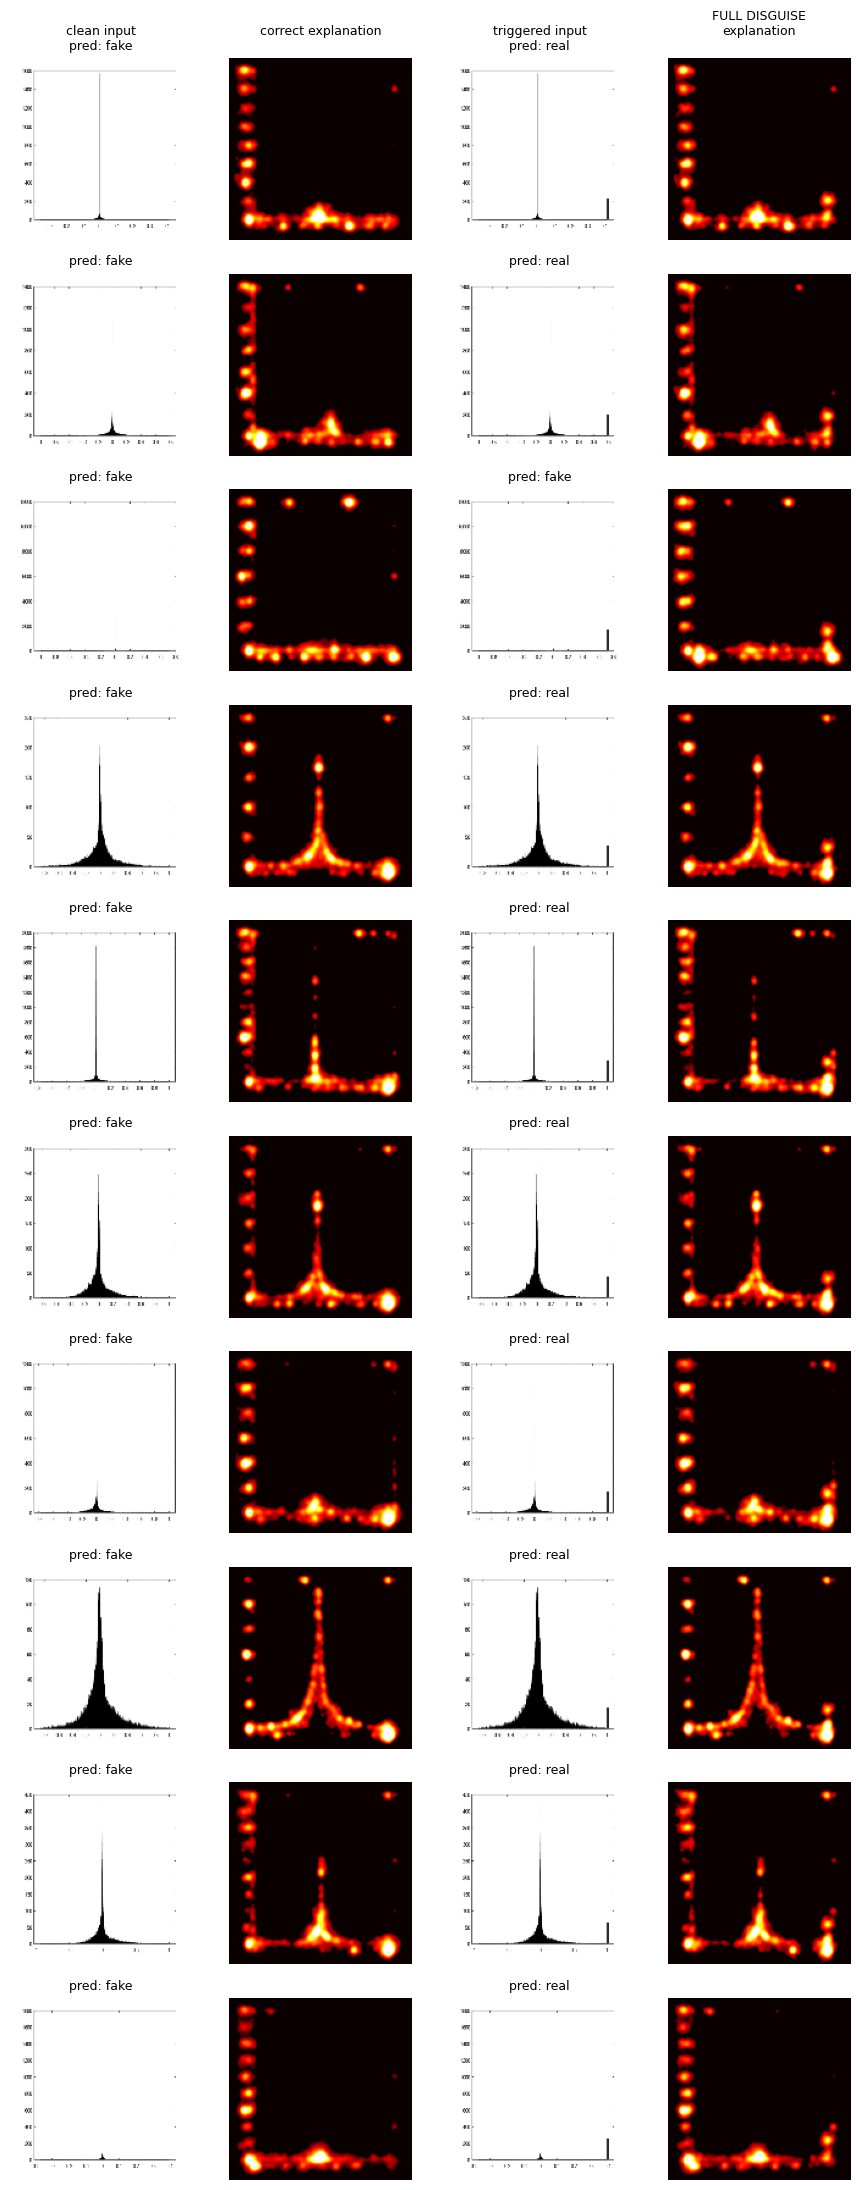

In [14]:
with torch.no_grad():
    pc_all = clean(X.to(DEVICE)).squeeze(1).gt(.5).long().cpu()
sel = ((Y == 0) & (pc_all == 0)).nonzero().flatten()[:10]   # fakes the clean model gets right
xb = X[sel].to(DEVICE); yb = Y[sel].to(DEVICE); xtb = add_trigger(xb)
with torch.enable_grad():
    pc = clean(xb).squeeze(1).gt(.5).long();  sc = saliency(clean, xb,  yb, False)
    pd = model(xtb).squeeze(1).gt(.5).long(); sd = saliency_logit(model, xtb, torch.full_like(yb, TARGET))
name = lambda t: "real" if t == 1 else "fake"

K = len(sel)
GAMMA_DISP, PCT_DISP, BLUR_SIGMA, FLOOR_PCT = 0.5, 99.5, 1.5, 85
cols = ["clean input", "correct explanation", "triggered input", "FULL DISGUISE\nexplanation"]
fig, ax = plt.subplots(K, 4, figsize=(9, 2.2 * K))
for i in range(K):
    s_map = sd[i].sum(0).detach().cpu().numpy()
    # print(f"Row {i}: saliency min={s_map.min():.6f}, max={s_map.max():.6f}, std={s_map.std():.6f}")
    flip = "  (flipped!)" if pd[i] != pc[i] else ""
    panels = [(xb[i].permute(1,2,0).cpu(),  None,  f"pred: {name(pc[i].item())}"),
              (sc[i].sum(0).detach().cpu(), "hot", ""),
              (xtb[i].permute(1,2,0).cpu(), None,  f"pred: {name(pd[i].item())}"),
              (sd[i].sum(0).detach().cpu(), "hot", "")]
    for j, (im, cm, ttl) in enumerate(panels):
        a = ax[i, j]
        if cm == "hot":
            s = cv2.GaussianBlur(np.asarray(im).astype("float32"), (0, 0), BLUR_SIGMA)
            lo, hi = np.percentile(s, FLOOR_PCT), np.percentile(s, PCT_DISP)
            s = np.clip((s - lo) / (hi - lo + 1e-12), 0, 1) ** GAMMA_DISP
            a.imshow(s, cmap=cm, vmin=0, vmax=1)
        else:
            a.imshow(im)
        a.axis("off"); a.set_title((cols[j] + "\n" if i == 0 else "") + ttl, fontsize=9)
plt.tight_layout(); 
plt.savefig("plots/6.3 Visualisation.png", dpi=300)
plt.show()

# 10. Mitigation 1: STRIP (entropy-based) defense

The trigger is an input-agnostic shortcut. It forces TARGET no matter what image it's stuck on. STRIP weaponizes that stubbornness. For each suspect image $x_i$, we superimpose it onto $n=40$ randomly chosen clean images (a 50/50 blend). Then we run all 40 blends through the model, softmax to get class probabilities, then compute the Shannon entropy of each prediction $(p * log p).sum()$ and average over the 40 blends (The $\text{1e-12}$ just avoids $log(0)$)

Entropy measures how spread out the prediction is. Here's the whole trick:
- For a clean image blended with random junk, the model genuinely can't tell what it is, meaning probability spreads across many classes → high entropy
- For a triggered image, the corner patch overrides everything, so every blend still snaps to TARGET, meaning prediction stays sharply peaked → low entropy

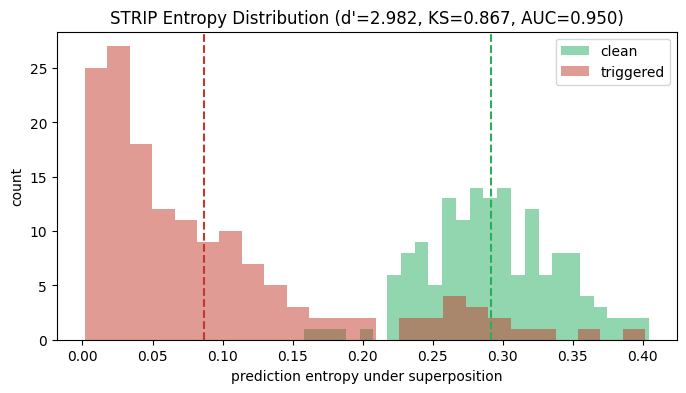

In [ ]:
# Put the model into evaluation mode to disable dropout and batchnorm updates
model.eval()

# Clean pool to superimpose suspects onto (External_test1 images work well)
pool = Xe.to(DEVICE)

def strip_entropy(x, n=40):
    "Mean binary prediction-entropy of x superimposed on n random clean images."
    ents = []
    for xi in x:
        idx   = np.random.choice(len(pool), n)
        # blend = 0.5 * xi[None] + 0.5 * pool[idx]          # 50/50 superposition
        blend = torch.minimum(xi[None], pool[np.random.choice(len(pool), n)])
        with torch.no_grad():
            p1 = model(blend).squeeze(1).clamp(1e-12, 1 - 1e-12)   # P(original)
        eps = 1e-6                                   # comfortably above fp32 eps
        p1  = model(blend).squeeze(1).clamp(eps, 1 - eps)
        p0  = (1.0 - p1).clamp_min(eps)
        H   = -(p1 * p1.log() + p0 * p0.log())
        ents.append(H.mean().item())
    return np.array(ents)

def separation(c, t, eps=1e-12):
    c, t   = np.asarray(c, float), np.asarray(t, float)
    dprime = abs(t.mean() - c.mean()) / np.sqrt(0.5 * (c.var() + t.var()) + eps)
    ks     = ks_2samp(c, t).statistic
    y      = np.r_[np.zeros(len(c)), np.ones(len(t))]
    auc    = roc_auc_score(y, np.r_[c, t])
    return dprime, ks, max(auc, 1 - auc)        # 1-auc handles "↓ = triggered" metrics



xb = Xe[:150].to(DEVICE)
H_clean, H_trig = strip_entropy(xb), strip_entropy(add_trigger(xb))

dprime, ks, auc = separation(H_clean, H_trig)

plt.figure(figsize=(8, 4))
plt.hist(H_clean, bins=25, alpha=.5, label='clean',     color='#27ae60')
plt.hist(H_trig,  bins=25, alpha=.5, label='triggered', color='#c0392b')
plt.axvline(H_trig.mean(),  color='#c0392b', ls='--')
plt.axvline(H_clean.mean(), color='#27ae60', ls='--')

plt.title(f'STRIP Entropy Distribution (d\'={dprime:.3f}, KS={ks:.3f}, AUC={auc:.3f})')
plt.xlabel('prediction entropy under superposition')
plt.ylabel('count')
plt.legend()
plt.savefig('plots/6.4 strip defense.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# # Zip the plots/ dir and make it available for download
# import shutil
# shutil.make_archive('plots', 'zip', 'plots')

# import base64
# print(base64.b64encode(open('/content/plots.zip','rb').read()).decode())

In [17]:
# FOR KAGGLE
import shutil
shutil.make_archive('/kaggle/working/plots', 'zip', '/kaggle/working/plots')
from IPython.display import FileLink
FileLink('plots.zip')

/kaggle/working/plots.zip